# CartPole Value Iteration (Corrected)

This notebook implements Value Iteration for the CartPole system with `c1=0` and `c2=0`. 
It addresses the "mostly 0" policy issue by:
1. Increasing resolution (`N_BINS=50`).
2. Handling indifference (assigning 0.5 when actions are equal).
3. Using a higher `TERMINAL_COST` to encourage balancing.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# --- HYPERPARAMETERS ---
# Increased resolution to avoid "Dead Zones"
N_BINS = 50 

# State Limits
X_LIMIT = 2.4
THETA_LIMIT = np.deg2rad(12)
X_VEL_LIMIT = 4.8
THETA_VEL_LIMIT = np.deg2rad(400)

# Cost Parameters
GAMMA = 0.5
# User requested c1 and c2 to be default zero
CART_COST_WEIGHT = 0.0
POLE_ANGLE_COST_WEIGHT = 0.0
# Increased Terminal Cost to discourage crashing
TERMINAL_COST = 100.0 

# VI Parameters
N_ITERATIONS = 2000
DELTA = 0.01

In [5]:
# --- STATE SPACE GENERATION ---
x_vals = np.linspace(-X_LIMIT, X_LIMIT, N_BINS)
x_dot_vals = np.linspace(-X_VEL_LIMIT, X_VEL_LIMIT, N_BINS)
theta_vals = np.linspace(-THETA_LIMIT, THETA_LIMIT, N_BINS)
theta_dot_vals = np.linspace(-THETA_VEL_LIMIT, THETA_VEL_LIMIT, N_BINS)

grids = [x_vals, x_dot_vals, theta_vals, theta_dot_vals]

# Create Mesh
mesh = np.meshgrid(x_vals, x_dot_vals, theta_vals, theta_dot_vals, indexing='ij')
state_tensor = np.array(mesh)

# Identify Terminal States
is_terminal = (state_tensor[2] <= theta_vals[0]) | (state_tensor[2] >= theta_vals[-1]) | \
              (state_tensor[0] <= x_vals[0]) | (state_tensor[0] >= x_vals[-1])

# --- DYNAMICS FUNCTION ---
def dynamics(state_tensor, action_val):
    GRAVITY = 9.8
    MASSCART = 1.0
    MASSPOLE = 0.1
    TOTAL_MASS = MASSPOLE + MASSCART
    LENGTH = 0.5
    TAU = 0.02
    FORCE_MAG = 10.0

    x, x_dot, theta, theta_dot = state_tensor
    # Action 0 = -Force (Left), Action 1 = +Force (Right)
    force = FORCE_MAG if action_val == 1 else -FORCE_MAG

    cos_t, sin_t = np.cos(theta), np.sin(theta)
    temp = (force + MASSPOLE * LENGTH * theta_dot**2 * sin_t) / TOTAL_MASS
    thetaacc = (GRAVITY * sin_t - cos_t * temp) / (LENGTH * (4.0/3.0 - MASSPOLE * cos_t**2 / TOTAL_MASS))
    xacc = temp - MASSPOLE * LENGTH * thetaacc * cos_t / TOTAL_MASS

    # Euler Integration
    next_x = x + TAU * x_dot
    next_x_dot = np.clip(x_dot + TAU * xacc, -X_VEL_LIMIT, X_VEL_LIMIT)
    next_theta = theta + TAU * theta_dot
    next_theta_dot = np.clip(theta_dot + TAU * thetaacc, -THETA_VEL_LIMIT, THETA_VEL_LIMIT)

    return np.array([next_x, next_x_dot, next_theta, next_theta_dot])

def state_to_indices(state, grids):
    indices = []
    for i in range(4):
        grid = grids[i]
        step = grid[1] - grid[0]
        # Calculate index (vectorized)
        idx = np.round((state[i] - grid[0]) / step).astype(int)
        indices.append(np.clip(idx, 0, len(grid) - 1))
    return tuple(indices)

def quadratic_cost(state, c1=CART_COST_WEIGHT, c2=POLE_ANGLE_COST_WEIGHT):
    x = state[0]
    theta = state[2]
    return c1 * x**2 + c2 * theta**2

In [6]:
# --- VALUE ITERATION ---
print("Initializing Value Iteration...")

# Initialize V
V = np.zeros((N_BINS, N_BINS, N_BINS, N_BINS))

# Pre-compute dynamics to speed up the loop
print("Pre-computing next states...")
next_states_0 = dynamics(state_tensor, 0) # Left
next_indices_0 = state_to_indices(next_states_0, grids)

next_states_1 = dynamics(state_tensor, 1) # Right
next_indices_1 = state_to_indices(next_states_1, grids)

current_costs = quadratic_cost(state_tensor)

print("Starting Loop...")
for i in tqdm(range(N_ITERATIONS)):
    # Calculate Value for Action 0 (Left)
    # If next state is terminal, cost is TERMINAL_COST. Else V[next]
    term_mask_0 = is_terminal[next_indices_0]
    v_next_0 = np.where(term_mask_0, TERMINAL_COST, V[next_indices_0])
    Q0 = current_costs + GAMMA * v_next_0
    
    # Calculate Value for Action 1 (Right)
    term_mask_1 = is_terminal[next_indices_1]
    v_next_1 = np.where(term_mask_1, TERMINAL_COST, V[next_indices_1])
    Q1 = current_costs + GAMMA * v_next_1
    
    # Bellman Update
    V_new = np.minimum(Q0, Q1)
    
    diff = np.max(np.abs(V - V_new))
    V = V_new
    
    if diff < DELTA:
        print(f"Converged at iteration {i} with delta {diff}")
        break

print("Value Iteration Complete.")

Initializing Value Iteration...
Pre-computing next states...
Starting Loop...


  1%|          | 13/2000 [00:05<13:28,  2.46it/s]

Converged at iteration 13 with delta 0.006103515625
Value Iteration Complete.


In [7]:
# --- COMPUTE POLICY (With Indifference Fix) ---

# Re-calculate Q-values one last time
term_mask_0 = is_terminal[next_indices_0]
v_next_0 = np.where(term_mask_0, TERMINAL_COST, V[next_indices_0])
Q0 = current_costs + GAMMA * v_next_0

term_mask_1 = is_terminal[next_indices_1]
v_next_1 = np.where(term_mask_1, TERMINAL_COST, V[next_indices_1])
Q1 = current_costs + GAMMA * v_next_1

# 1. Determine base policy (0 or 1)
# 0 = Left, 1 = Right
policy_indices = np.argmin([Q0, Q1], axis=0)
policy = policy_indices.astype(float)

# 2. Handle Indifference (Dead Zones)
# If Q0 and Q1 are very close, the agent is indifferent.
# We assign 0.5 to visualize this symmetry.
diff = np.abs(Q0 - Q1)
tolerance = 1e-6

policy[diff < tolerance] = 0.5

print("Policy computed.")

Policy computed.


Plotting slice at x_dot ~ -0.10, theta_dot ~ -0.14


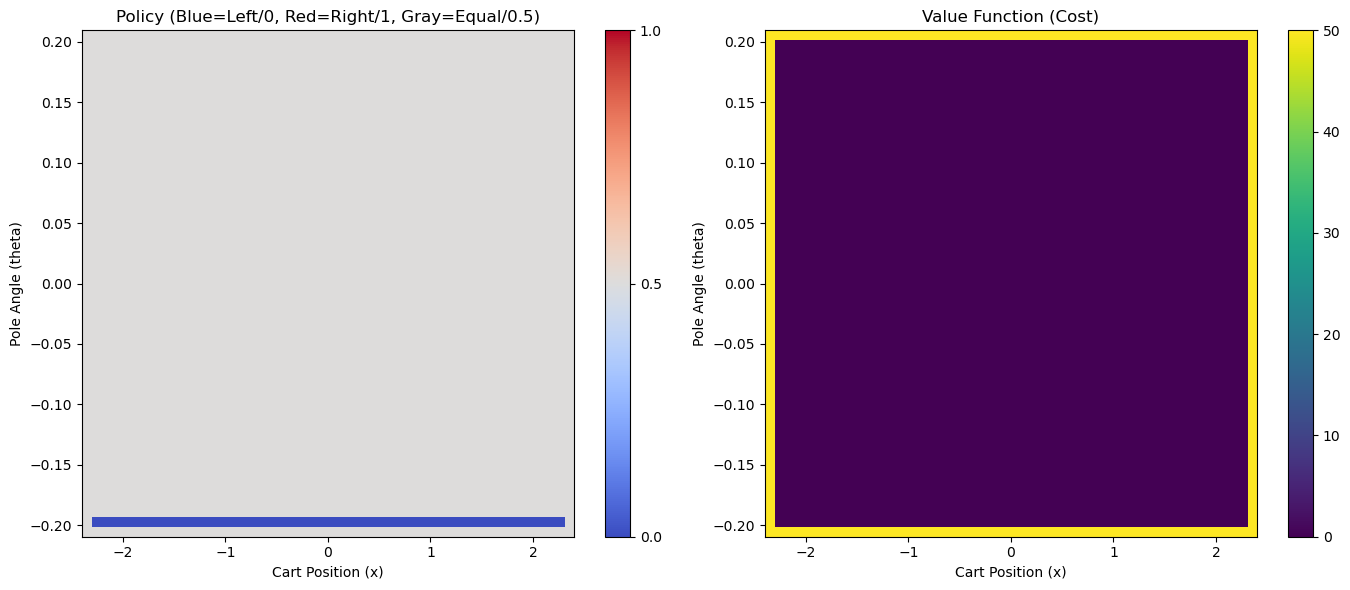

In [8]:
# --- PLOTTING ---
def plot_policy_slice(policy, V, x_dot_idx, theta_dot_idx):
    # Prepare Plot
    fig, ax = plt.subplots(1, 2, figsize=(14, 6))

    # Extent for imshow
    extent = [x_vals[0], x_vals[-1], theta_vals[0], theta_vals[-1]]

    # 1. Policy Plot
    # Slice: x (axis 0) vs theta (axis 2)
    # Dimensions: (x, x_dot, theta, theta_dot)
    # We want x on X-axis, theta on Y-axis.
    # Slicing: policy[:, x_dot_idx, :, theta_dot_idx] -> Shape (N_BINS, N_BINS)
    # imshow expects (Rows/Y, Cols/X). So we need Transpose.
    pol_slice = policy[:, x_dot_idx, :, theta_dot_idx].T
    
    im1 = ax[0].imshow(pol_slice, origin='lower', extent=extent, cmap='coolwarm', aspect='auto', vmin=0, vmax=1)
    ax[0].set_title('Policy (Blue=Left/0, Red=Right/1, Gray=Equal/0.5)')
    ax[0].set_xlabel('Cart Position (x)')
    ax[0].set_ylabel('Pole Angle (theta)')
    fig.colorbar(im1, ax=ax[0], ticks=[0, 0.5, 1])

    # 2. Value Plot
    val_slice = V[:, x_dot_idx, :, theta_dot_idx].T
    im2 = ax[1].imshow(val_slice, origin='lower', extent=extent, cmap='viridis', aspect='auto')
    ax[1].set_title('Value Function (Cost)')
    ax[1].set_xlabel('Cart Position (x)')
    ax[1].set_ylabel('Pole Angle (theta)')
    fig.colorbar(im2, ax=ax[1])

    plt.tight_layout()
    plt.show()

# Find indices for zero velocity
idx_x_dot_0 = np.argmin(np.abs(x_dot_vals))
idx_theta_dot_0 = np.argmin(np.abs(theta_dot_vals))

print(f"Plotting slice at x_dot ~ {x_dot_vals[idx_x_dot_0]:.2f}, theta_dot ~ {theta_dot_vals[idx_theta_dot_0]:.2f}")
plot_policy_slice(policy, V, idx_x_dot_0, idx_theta_dot_0)